In [168]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets , transforms
from torchvision.transforms import ToTensor

In [169]:
# Download training data from open datasets.
training_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor(),  # Convert PIL Image to tensor
    # Normalize pixel values to [0, 1] (default for ToTensor)
)

# Download test data from open datasets.
test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor(),  # Convert PIL Image to tensor
)

In [170]:
batch_size = 100

# Create data loaders.
train_dataloader = DataLoader(training_data, 
                              batch_size=batch_size,
                              shuffle=True     # Shuffle training data
                              )
test_dataloader = DataLoader(test_data, batch_size=batch_size)

for X, y in test_dataloader:
    print(f"Shape of X [N, C, H, W]: {X.shape}")
    print(f"Shape of y: {y.shape} {y.dtype}")
    break

Shape of X [N, C, H, W]: torch.Size([100, 1, 28, 28])
Shape of y: torch.Size([100]) torch.int64


In [171]:
# device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
# print(f"Using {device} device")
device = "cuda" if torch.cuda.is_available() else "cpu"
# Define neural network model
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()  # Flatten 28x28 image to 784-dim vector
        
        # Define the network architecture
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(28*28, 256),  # First hidden layer
            nn.ReLU(),               # Activation function
            nn.Dropout(0.3),         # Dropout for regularization
            nn.Linear(256, 128),     # Third hidden layer
            nn.ReLU(),               # Activation function
            nn.Dropout(0.3),         # Dropout for regularization
            nn.Linear(128, 10)       # Output layer (10 classes)
        )

    def forward(self, x):
        x = self.flatten(x)  # Flatten the input
        return self.linear_relu_stack(x)  # Pass through the network

# Initialize model and move to device
model = NeuralNetwork().to(device)
print(model)  # Print model architecture

NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=128, out_features=10, bias=True)
  )
)


In [172]:
# Define loss function and optimizer
loss_fn = nn.CrossEntropyLoss()  # Suitable for multi-class classification
optimizer = torch.optim.Adam(    # Adam optimizer often works well
    model.parameters(), 
    lr=0.001 ,
    weight_decay=1e-5  # L2 regularization
)

In [173]:
# Lists to store loss values
train_losses = []
test_losses = []
train_accuracies = []
test_accuracies = []

In [ ]:
def train(dataloader, model, loss_fn, optimizer):
    model.train() # Set model to training mode (enables dropout/batch norm)
    running_loss = 0.0
    correct = 0
    total = 0
    
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad() # Clears old gradients
        pred = model(X) 
        loss = loss_fn(pred, y)
        
        loss.backward()  # Computes gradients
        optimizer.step()  # Updates model weights
        
        running_loss += loss.item()
        _, predicted = torch.max(pred.data, 1) # Gets the model's predicted class labels
        total += y.size(0) #  Counts total number of examples processed
        correct += (predicted == y).sum().item() #  Counts number of correct predictions
    
    epoch_loss = running_loss / len(dataloader) # Calculates average loss and accuracy per batch
    epoch_acc = 100 * correct / total  # Calculates accuracy per batch
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)
    return epoch_loss, epoch_acc

In [175]:
def test(dataloader, model, loss_fn):
    model.eval()  # Set model to evaluation mode (no dropout/batch norm)
    test_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item() # Tracks total loss 
            _, predicted = torch.max(pred.data, 1)  
            total += y.size(0)
            correct += (predicted == y).sum().item()
    
    epoch_loss = test_loss / len(dataloader)
    epoch_acc = 100 * correct / total
    test_losses.append(epoch_loss)
    test_accuracies.append(epoch_acc)
    return epoch_loss, epoch_acc

In [176]:
# Training loop
epochs = 5
for epoch in range(epochs):
    train_loss, train_acc = train(train_dataloader, model, loss_fn, optimizer)
    test_loss, test_acc = test(test_dataloader, model, loss_fn)
    
    print(f"Epoch {epoch+1}/{epochs}")
    print(f"Train Loss: {train_loss:.4f} | Test Loss: {test_loss:.4f}")
    print(f"Train Acc: {train_acc:.2f}% | Test Acc: {test_acc:.2f}%\n")

Epoch 1/5
Train Loss: 0.6164 | Test Loss: 0.4440
Train Acc: 77.87% | Test Acc: 83.98%

Epoch 2/5
Train Loss: 0.4291 | Test Loss: 0.4100
Train Acc: 84.63% | Test Acc: 84.72%

Epoch 3/5
Train Loss: 0.3917 | Test Loss: 0.3947
Train Acc: 85.72% | Test Acc: 85.46%

Epoch 4/5
Train Loss: 0.3679 | Test Loss: 0.3631
Train Acc: 86.60% | Test Acc: 86.70%

Epoch 5/5
Train Loss: 0.3509 | Test Loss: 0.3597
Train Acc: 87.11% | Test Acc: 86.94%



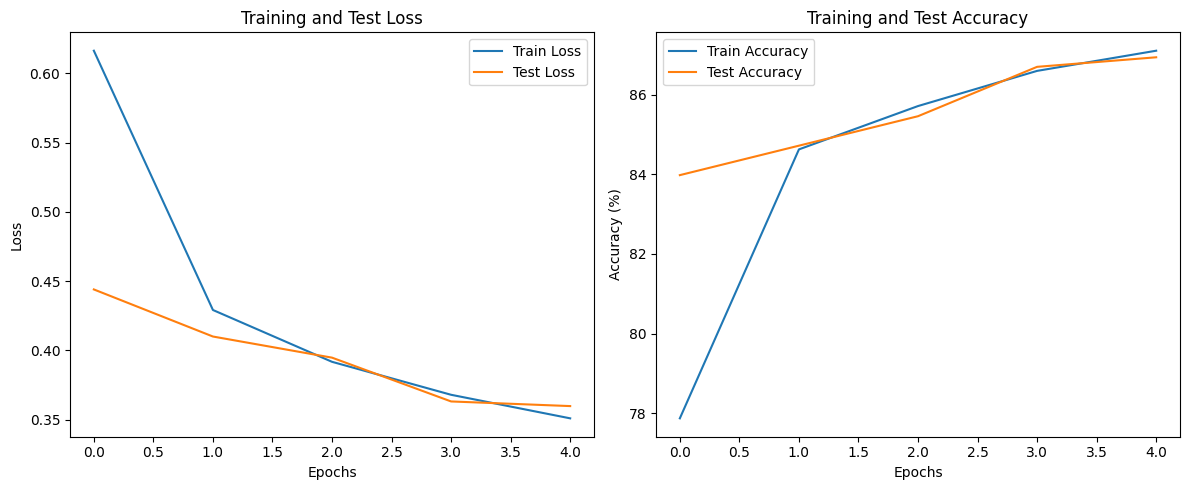

Final Training Accuracy: 87.11%
Final Test Accuracy: 86.94%
Final Training Loss: 0.3509
Final Test Loss: 0.3597


In [177]:
from matplotlib import pyplot as plt
# Plotting
plt.figure(figsize=(12, 5))
# Loss plot
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.title('Training and Test Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Accuracy plot
plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(test_accuracies, label='Test Accuracy')
plt.title('Training and Test Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.tight_layout()
plt.show()

# Print final metrics
print(f"Final Training Accuracy: {train_accuracies[-1]:.2f}%")
print(f"Final Test Accuracy: {test_accuracies[-1]:.2f}%")
print(f"Final Training Loss: {train_losses[-1]:.4f}")
print(f"Final Test Loss: {test_losses[-1]:.4f}")

In [178]:
torch.save(model.state_dict(), "model.pth")
print("Saved PyTorch Model State to model.pth")

Saved PyTorch Model State to model.pth


In [179]:
model = NeuralNetwork().to(device)
model.load_state_dict(torch.load("model.pth", weights_only=True))

<All keys matched successfully>